In [4]:
import cv2
import sys
import numpy as np
from typing import Tuple, Optional

class RealTimeObjectTracker:
    """
    Real-time object tracker using OpenCV's built-in tracking algorithms.
    Supports multiple tracking algorithms: CSRT, KCF, BOOSTING, MIL, TLD, MEDIANFLOW, GOTURN, MOSSE
    """
    
    def __init__(self, tracker_type: str = 'CSRT'):
        """
        Initialize the tracker with specified algorithm.
        
        Args:
            tracker_type: Type of tracker to use ('CSRT', 'KCF', 'BOOSTING', etc.)
        """
        self.tracker_type = tracker_type
        self.tracker = None
        self.cap = None
        self.tracking = False
        self.bbox = None
        
        # Initialize tracker based on type
        self.tracker = self._create_tracker(tracker_type)
        
    def _create_tracker(self, tracker_type: str):
        """Create tracker object based on specified type."""
        tracker_types = {
            'BOOSTING': cv2.legacy.TrackerBoosting_create,
            'MIL': cv2.legacy.TrackerMIL_create,
            'KCF': cv2.legacy.TrackerKCF_create,
            'TLD': cv2.legacy.TrackerTLD_create,
            'MEDIANFLOW': cv2.legacy.TrackerMedianFlow_create,
            'GOTURN': cv2.TrackerGOTURN_create,
            'MOSSE': cv2.legacy.TrackerMOSSE_create,
            'CSRT': cv2.TrackerCSRT_create
        }
        
        if tracker_type in tracker_types:
            return tracker_types[tracker_type]()
        else:
            print(f"Tracker type '{tracker_type}' not supported. Using CSRT instead.")
            return tracker_types['CSRT']()
    
    def initialize_camera(self, camera_index: int = 0) -> bool:
        """
        Initialize camera capture.
        
        Args:
            camera_index: Camera index (0 for default camera)
            
        Returns:
            bool: True if camera initialized successfully
        """
        self.cap = cv2.VideoCapture(camera_index)
        
        if not self.cap.isOpened():
            print("Error: Could not open camera")
            return False
            
        # Set camera properties for better performance
        self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        self.cap.set(cv2.CAP_PROP_FPS, 30)
        
        return True
    
    def select_object(self, frame: np.ndarray) -> Optional[Tuple[int, int, int, int]]:
        """
        Allow user to select object by drawing bounding box.
        
        Args:
            frame: Input frame for object selection
            
        Returns:
            Tuple of (x, y, width, height) or None if selection cancelled
        """
        print("Select object to track. Press ENTER to confirm, ESC to cancel.")
        
        # Use OpenCV's selectROI function for interactive bounding box selection
        bbox = cv2.selectROI("Select Object", frame, False, False)
        cv2.destroyWindow("Select Object")
        
        if bbox[2] > 0 and bbox[3] > 0:  # Valid selection
            return bbox
        else:
            return None
    
    def start_tracking(self) -> None:
        """Main tracking loop."""
        if not self.initialize_camera():
            return
        
        print("Real-Time Object Tracker")
        print(f"Using {self.tracker_type} tracker")
        print("Instructions:")
        print("- Select an object in the first frame")
        print("- Press 'r' to reset and select new object")
        print("- Press 'q' to quit")
        print("-" * 50)
        
        frame_count = 0
        fps_counter = 0
        fps_start_time = cv2.getTickCount()
        
        while True:
            ret, frame = self.cap.read()
            if not ret:
                print("Error: Could not read frame")
                break
            
            frame_count += 1
            
            # Flip frame horizontally for mirror effect
            frame = cv2.flip(frame, 1)
            
            if not self.tracking:
                # Display instruction text
                cv2.putText(frame, "Press 's' to select object", (10, 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(frame, f"Tracker: {self.tracker_type}", (10, 60), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            else:
                # Update tracker
                success, bbox = self.tracker.update(frame)
                
                if success:
                    # Draw bounding box
                    x, y, w, h = [int(i) for i in bbox]
                    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                    
                    # Draw center point
                    center_x, center_y = x + w // 2, y + h // 2
                    cv2.circle(frame, (center_x, center_y), 5, (0, 255, 0), -1)
                    
                    # Display tracking info
                    cv2.putText(frame, f"Tracking: {self.tracker_type}", (x, y - 10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
                    cv2.putText(frame, f"Pos: ({center_x}, {center_y})", (x, y + h + 20), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
                else:
                    # Tracking failed
                    cv2.putText(frame, "Tracking Lost! Press 'r' to reset", (10, 30), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            
            # Calculate and display FPS
            fps_counter += 1
            if fps_counter >= 30:  # Update FPS every 30 frames
                fps_end_time = cv2.getTickCount()
                fps = 30 / ((fps_end_time - fps_start_time) / cv2.getTickFrequency())
                fps_start_time = fps_end_time
                fps_counter = 0
            else:
                fps = 0
            
            if fps > 0:
                cv2.putText(frame, f"FPS: {fps:.1f}", (frame.shape[1] - 100, 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            
            # Display frame
            cv2.imshow('Real-Time Object Tracker', frame)
            
            # Handle key presses
            key = cv2.waitKey(1) & 0xFF
            
            if key == ord('q'):
                break
            elif key == ord('s') and not self.tracking:
                # Select object
                bbox = self.select_object(frame)
                if bbox:
                    self.bbox = bbox
                    # Reinitialize tracker
                    self.tracker = self._create_tracker(self.tracker_type)
                    success = self.tracker.init(frame, bbox)
                    if success:
                        self.tracking = True
                        print(f"Object selected and tracking started with {self.tracker_type}")
                    else:
                        print("Failed to initialize tracker")
            elif key == ord('r'):
                # Reset tracking
                self.tracking = False
                self.tracker = self._create_tracker(self.tracker_type)
                print("Tracking reset. Press 's' to select new object.")
        
        # Cleanup
        self.cap.release()
        cv2.destroyAllWindows()

def main():
    """Main function to run the object tracker."""
    # Available tracker types
    available_trackers = ['CSRT', 'KCF', 'BOOSTING', 'MIL', 'TLD', 'MEDIANFLOW', 'MOSSE']
    
    # Default tracker
    tracker_type = 'CSRT'
    
    # Parse command line arguments
    if len(sys.argv) > 1:
        requested_tracker = sys.argv[1].upper()
        if requested_tracker in available_trackers:
            tracker_type = requested_tracker
        else:
            print(f"Tracker '{sys.argv[1]}' not available. Using CSRT instead.")
            print(f"Available trackers: {', '.join(available_trackers)}")
    
    # Create and start tracker
    tracker = RealTimeObjectTracker(tracker_type)
    tracker.start_tracking()

if __name__ == "__main__":
    main()


Tracker '-f' not available. Using CSRT instead.
Available trackers: CSRT, KCF, BOOSTING, MIL, TLD, MEDIANFLOW, MOSSE
Real-Time Object Tracker
Using CSRT tracker
Instructions:
- Select an object in the first frame
- Press 'r' to reset and select new object
- Press 'q' to quit
--------------------------------------------------
Tracking reset. Press 's' to select new object.
Tracking reset. Press 's' to select new object.


In [5]:
import cv2
import sys
import numpy as np
import time
from typing import Tuple, Optional, Dict

class RealTimeObjectTracker:
    """
    Real-time object tracker using OpenCV's tracking algorithms.
    Supports interactive object selection and multiple tracking algorithms.
    """
    
    def __init__(self, tracker_type: str = 'CSRT'):
        """
        Initialize the tracker with specified algorithm.
        
        Args:
            tracker_type: Type of tracker ('CSRT', 'KCF', 'BOOSTING', 'MIL', 'MOSSE')
        """
        self.tracker_type = tracker_type
        self.tracker = None
        self.cap = None
        self.tracking = False
        self.bbox = None
        self.frame_count = 0
        self.fps = 0
        self.fps_start_time = time.time()
        
        # Performance metrics
        self.tracking_success_count = 0
        self.total_tracking_frames = 0
        
        # Colors for visualization
        self.colors = {
            'success': (0, 255, 0),    # Green
            'failure': (0, 0, 255),    # Red
            'text': (255, 255, 255),   # White
            'info': (0, 255, 255)      # Yellow
        }
        
        print(f"Initializing Real-Time Object Tracker with {tracker_type}")
        
    def _create_tracker(self, tracker_type: str):
        """Create tracker object based on specified type."""
        tracker_types = {
            'BOOSTING': cv2.legacy.TrackerBoosting_create,
            'MIL': cv2.legacy.TrackerMIL_create,
            'KCF': cv2.legacy.TrackerKCF_create,
            'TLD': cv2.legacy.TrackerTLD_create,
            'MEDIANFLOW': cv2.legacy.TrackerMedianFlow_create,
            'MOSSE': cv2.legacy.TrackerMOSSE_create,
            'CSRT': cv2.TrackerCSRT_create
        }
        
        try:
            if tracker_type in tracker_types:
                return tracker_types[tracker_type]()
            else:
                print(f"Warning: Tracker '{tracker_type}' not supported. Using CSRT.")
                return tracker_types['CSRT']()
        except Exception as e:
            print(f"Error creating tracker: {e}")
            return tracker_types['CSRT']()
    
    def initialize_camera(self, camera_index: int = 0) -> bool:
        """
        Initialize camera capture with optimal settings.
        
        Args:
            camera_index: Camera index (0 for default camera)
            
        Returns:
            bool: True if camera initialized successfully
        """
        self.cap = cv2.VideoCapture(camera_index)
        
        if not self.cap.isOpened():
            print("Error: Could not open camera. Please check camera connection.")
            return False
        
        # Set optimal camera properties
        self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        self.cap.set(cv2.CAP_PROP_FPS, 30)
        self.cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)  # Reduce latency
        
        # Test camera
        ret, test_frame = self.cap.read()
        if not ret:
            print("Error: Could not read from camera.")
            return False
            
        print(f"Camera initialized successfully: {int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")
        return True
    
    def select_object(self, frame: np.ndarray) -> Optional[Tuple[int, int, int, int]]:
        """
        Interactive object selection using bounding box.
        
        Args:
            frame: Input frame for object selection
            
        Returns:
            Tuple of (x, y, width, height) or None if cancelled
        """
        print("\n" + "="*50)
        print("OBJECT SELECTION")
        print("="*50)
        print("Instructions:")
        print("1. Click and drag to draw a bounding box around the object")
        print("2. Press ENTER or SPACE to confirm selection")
        print("3. Press ESC or 'c' to cancel")
        print("4. Make sure the object is clearly visible and well-lit")
        
        # Create a copy for selection
        selection_frame = frame.copy()
        
        # Use OpenCV's selectROI for interactive selection
        bbox = cv2.selectROI("Select Object to Track", selection_frame, False, False)
        cv2.destroyWindow("Select Object to Track")
        
        if bbox[2] > 0 and bbox[3] > 0:
            print(f"✓ Object selected: {bbox}")
            return bbox
        else:
            print("✗ Selection cancelled or invalid")
            return None
    
    def calculate_fps(self) -> float:
        """Calculate current FPS."""
        self.frame_count += 1
        if self.frame_count >= 30:  # Update every 30 frames
            current_time = time.time()
            self.fps = 30 / (current_time - self.fps_start_time)
            self.fps_start_time = current_time
            self.frame_count = 0
        return self.fps
    
    def draw_tracking_info(self, frame: np.ndarray, bbox: Tuple[int, int, int, int], 
                          success: bool) -> np.ndarray:
        """
        Draw tracking information on frame.
        
        Args:
            frame: Input frame
            bbox: Bounding box coordinates
            success: Whether tracking was successful
            
        Returns:
            Frame with tracking information drawn
        """
        if success:
            x, y, w, h = [int(i) for i in bbox]
            
            # Draw main bounding box
            cv2.rectangle(frame, (x, y), (x + w, y + h), self.colors['success'], 2)
            
            # Draw center point
            center_x, center_y = x + w // 2, y + h // 2
            cv2.circle(frame, (center_x, center_y), 5, self.colors['success'], -1)
            
            # Draw corner markers for better visibility
            corner_size = 10
            cv2.line(frame, (x, y), (x + corner_size, y), self.colors['success'], 3)
            cv2.line(frame, (x, y), (x, y + corner_size), self.colors['success'], 3)
            cv2.line(frame, (x + w, y), (x + w - corner_size, y), self.colors['success'], 3)
            cv2.line(frame, (x + w, y), (x + w, y + corner_size), self.colors['success'], 3)
            cv2.line(frame, (x, y + h), (x + corner_size, y + h), self.colors['success'], 3)
            cv2.line(frame, (x, y + h), (x, y + h - corner_size), self.colors['success'], 3)
            cv2.line(frame, (x + w, y + h), (x + w - corner_size, y + h), self.colors['success'], 3)
            cv2.line(frame, (x + w, y + h), (x + w, y + h - corner_size), self.colors['success'], 3)
            
            # Object info
            cv2.putText(frame, f"TRACKING: {self.tracker_type}", (x, y - 10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, self.colors['success'], 2)
            cv2.putText(frame, f"Center: ({center_x}, {center_y})", (x, y + h + 20), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, self.colors['success'], 1)
            cv2.putText(frame, f"Size: {w}x{h}", (x, y + h + 35), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, self.colors['success'], 1)
        else:
            # Tracking failed
            cv2.putText(frame, "TRACKING LOST!", (50, 50), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1.0, self.colors['failure'], 2)
            cv2.putText(frame, "Press 'r' to reset or 's' to select new object", (50, 80), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.colors['failure'], 1)
        
        return frame
    
    def draw_ui_overlay(self, frame: np.ndarray) -> np.ndarray:
        """Draw UI overlay with controls and statistics."""
        height, width = frame.shape[:2]
        
        # Semi-transparent overlay for better text visibility
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (width, 120), (0, 0, 0), -1)
        frame = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)
        
        # FPS and performance info
        fps = self.calculate_fps()
        cv2.putText(frame, f"FPS: {fps:.1f}", (width - 120, 25), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, self.colors['text'], 2)
        
        if self.total_tracking_frames > 0:
            success_rate = (self.tracking_success_count / self.total_tracking_frames) * 100
            cv2.putText(frame, f"Success Rate: {success_rate:.1f}%", (width - 200, 50), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.colors['text'], 1)
        
        # Controls
        if not self.tracking:
            cv2.putText(frame, "Controls: 's' = Select Object | 'q' = Quit", (10, 25), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.colors['info'], 1)
            cv2.putText(frame, f"Tracker: {self.tracker_type}", (10, 50), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.colors['text'], 1)
        else:
            cv2.putText(frame, "Controls: 'r' = Reset | 's' = New Object | 'q' = Quit", (10, 25), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.colors['info'], 1)
        
        return frame
    
    def start_tracking(self) -> None:
        """Main tracking loop with comprehensive error handling."""
        if not self.initialize_camera():
            return
        
        print("\n" + "="*60)
        print("REAL-TIME OBJECT TRACKER - EYEGO INTERN TASK")
        print("="*60)
        print(f"Tracker Algorithm: {self.tracker_type}")
        print("Controls:")
        print("  's' - Select object to track")
        print("  'r' - Reset tracking")
        print("  'q' - Quit application")
        print("="*60)
        
        try:
            while True:
                ret, frame = self.cap.read()
                if not ret:
                    print("Error: Could not read frame from camera")
                    break
                
                # Flip frame horizontally for mirror effect (more intuitive)
                frame = cv2.flip(frame, 1)
                
                if self.tracking and self.tracker:
                    # Update tracker
                    start_time = time.time()
                    success, bbox = self.tracker.update(frame)
                    tracking_time = (time.time() - start_time) * 1000  # ms
                    
                    # Update statistics
                    self.total_tracking_frames += 1
                    if success:
                        self.tracking_success_count += 1
                    
                    # Draw tracking results
                    frame = self.draw_tracking_info(frame, bbox, success)
                    
                    # Display tracking time
                    cv2.putText(frame, f"Update Time: {tracking_time:.1f}ms", (10, 75), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, self.colors['text'], 1)
                
                # Draw UI overlay
                frame = self.draw_ui_overlay(frame)
                
                # Display frame
                cv2.imshow('Real-Time Object Tracker - Eyego', frame)
                
                # Handle keyboard input
                key = cv2.waitKey(1) & 0xFF
                
                if key == ord('q'):
                    print("Quitting application...")
                    break
                elif key == ord('s'):
                    # Select new object
                    bbox = self.select_object(frame)
                    if bbox:
                        # Initialize tracker
                        self.tracker = self._create_tracker(self.tracker_type)
                        success = self.tracker.init(frame, bbox)
                        
                        if success:
                            self.tracking = True
                            self.bbox = bbox
                            # Reset statistics
                            self.tracking_success_count = 0
                            self.total_tracking_frames = 0
                            print(f"✓ Tracking started with {self.tracker_type}")
                        else:
                            print("✗ Failed to initialize tracker")
                            self.tracking = False
                elif key == ord('r') and self.tracking:
                    # Reset tracking
                    self.tracking = False
                    self.tracker = None
                    print("Tracking reset. Press 's' to select new object.")
        
        except KeyboardInterrupt:
            print("\nInterrupted by user")
        except Exception as e:
            print(f"Unexpected error: {e}")
        finally:
            # Cleanup
            self.cleanup()
    
    def cleanup(self):
        """Clean up resources."""
        if self.cap:
            self.cap.release()
        cv2.destroyAllWindows()
        
        # Print final statistics
        if self.total_tracking_frames > 0:
            success_rate = (self.tracking_success_count / self.total_tracking_frames) * 100
            print(f"\nFinal Statistics:")
            print(f"  Total frames tracked: {self.total_tracking_frames}")
            print(f"  Successful frames: {self.tracking_success_count}")
            print(f"  Success rate: {success_rate:.1f}%")
        
        print("Application closed successfully.")

def main():
    """Main function with argument parsing."""
    # Available trackers
    available_trackers = ['CSRT', 'KCF', 'BOOSTING', 'MIL', 'MOSSE']
    
    # Parse command line arguments
    tracker_type = 'CSRT'  # Default to most accurate
    
    if len(sys.argv) > 1:
        requested_tracker = sys.argv[1].upper()
        if requested_tracker in available_trackers:
            tracker_type = requested_tracker
        else:
            print(f"Warning: Tracker '{sys.argv[1]}' not available.")
            print(f"Available trackers: {', '.join(available_trackers)}")
            print(f"Using default tracker: {tracker_type}")
    
    # Create and start tracker
    try:
        tracker = RealTimeObjectTracker(tracker_type)
        tracker.start_tracking()
    except Exception as e:
        print(f"Failed to start tracker: {e}")
        sys.exit(1)

if __name__ == "__main__":
    main()


Available trackers: CSRT, KCF, BOOSTING, MIL, MOSSE
Using default tracker: CSRT
Initializing Real-Time Object Tracker with CSRT
Camera initialized successfully: 640x480

REAL-TIME OBJECT TRACKER - EYEGO INTERN TASK
Tracker Algorithm: CSRT
Controls:
  's' - Select object to track
  'r' - Reset tracking
  'q' - Quit application

OBJECT SELECTION
Instructions:
1. Click and drag to draw a bounding box around the object
2. Press ENTER or SPACE to confirm selection
3. Press ESC or 'c' to cancel
4. Make sure the object is clearly visible and well-lit
✗ Selection cancelled or invalid

OBJECT SELECTION
Instructions:
1. Click and drag to draw a bounding box around the object
2. Press ENTER or SPACE to confirm selection
3. Press ESC or 'c' to cancel
4. Make sure the object is clearly visible and well-lit
✗ Selection cancelled or invalid
Quitting application...
Application closed successfully.


Tracker Benchmark Tool
This will compare the performance of different tracking algorithms


Enter benchmark duration in seconds (default 30):  10


Initializing trackers...
✓ CSRT tracker initialized
✓ KCF tracker initialized
✓ BOOSTING tracker initialized
✓ MIL tracker initialized
✓ MOSSE tracker initialized

Starting 10s benchmark with 5 trackers
Please select an object to track...
✗ CSRT initialization failed
✓ KCF initialized successfully
✓ BOOSTING initialized successfully
✓ MIL initialized successfully
✓ MOSSE initialized successfully
Running benchmark for 10 seconds...

TRACKER BENCHMARK RESULTS

KCF Tracker:
  Success Rate: 100.00%
  Average Update Time: 20.37 ± 4.08 ms
  Total Frames: 69
  Successful Frames: 69
  Min Update Time: 15.50 ms
  Max Update Time: 41.03 ms

BOOSTING Tracker:
  Success Rate: 100.00%
  Average Update Time: 37.98 ± 10.36 ms
  Total Frames: 69
  Successful Frames: 69
  Min Update Time: 28.13 ms
  Max Update Time: 82.74 ms

MIL Tracker:
  Success Rate: 100.00%
  Average Update Time: 75.14 ± 13.07 ms
  Total Frames: 69
  Successful Frames: 69
  Min Update Time: 57.41 ms
  Max Update Time: 116.93 ms

M

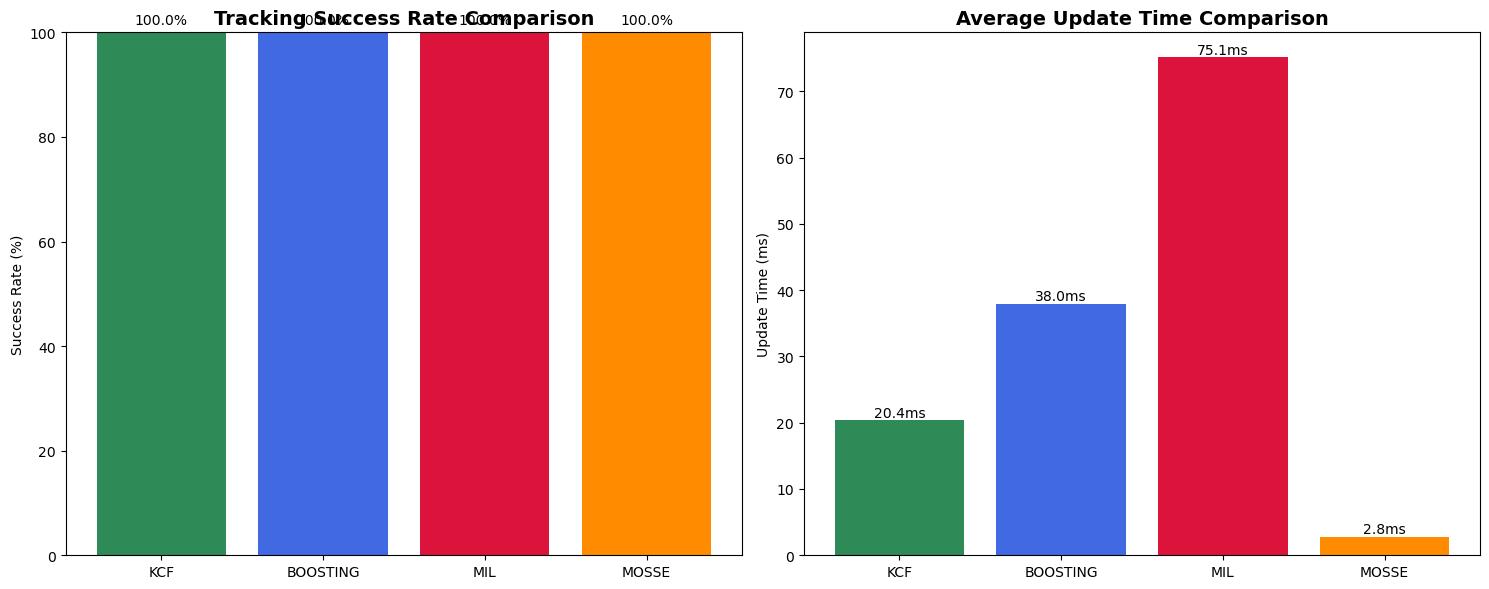

Performance plots saved as 'tracker_benchmark_results.png'


In [6]:
import cv2
import numpy as np
import time
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import json

class TrackerBenchmark:
    """
    Comprehensive benchmarking tool for different tracking algorithms.
    Provides performance comparison and analysis.
    """
    
    def __init__(self):
        self.trackers = {}
        self.tracker_names = ['CSRT', 'KCF', 'BOOSTING', 'MIL', 'MOSSE']
        self.cap = None
        self.results = {}
        
    def create_trackers(self) -> Dict:
        """Create all available tracking algorithms."""
        trackers = {}
        
        tracker_constructors = {
            'BOOSTING': cv2.legacy.TrackerBoosting_create,
            'MIL': cv2.legacy.TrackerMIL_create,
            'KCF': cv2.legacy.TrackerKCF_create,
            'MOSSE': cv2.legacy.TrackerMOSSE_create,
            'CSRT': cv2.TrackerCSRT_create
        }
        
        print("Initializing trackers...")
        for name in self.tracker_names:
            if name in tracker_constructors:
                try:
                    trackers[name] = tracker_constructors[name]()
                    print(f"✓ {name} tracker initialized")
                except Exception as e:
                    print(f"✗ Failed to initialize {name}: {e}")
        
        return trackers
    
    def run_benchmark(self, duration_seconds: int = 30):
        """
        Run comprehensive benchmark comparing all trackers.
        
        Args:
            duration_seconds: How long to run the benchmark
        """
        # Initialize camera
        self.cap = cv2.VideoCapture(0)
        if not self.cap.isOpened():
            print("Error: Could not open camera")
            return
        
        self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        
        # Create trackers
        self.trackers = self.create_trackers()
        if not self.trackers:
            print("No trackers available for benchmarking")
            return
        
        print(f"\nStarting {duration_seconds}s benchmark with {len(self.trackers)} trackers")
        print("Please select an object to track...")
        
        # Get first frame and select object
        ret, frame = self.cap.read()
        if not ret:
            print("Could not read initial frame")
            return
        
        frame = cv2.flip(frame, 1)
        bbox = cv2.selectROI("Select Object for Benchmark", frame, False, False)
        cv2.destroyWindow("Select Object for Benchmark")
        
        if bbox[2] <= 0 or bbox[3] <= 0:
            print("Invalid selection")
            return
        
        # Initialize all trackers
        initialized_trackers = {}
        for name, tracker in self.trackers.items():
            success = tracker.init(frame, bbox)
            if success:
                initialized_trackers[name] = tracker
                print(f"✓ {name} initialized successfully")
            else:
                print(f"✗ {name} initialization failed")
        
        if not initialized_trackers:
            print("No trackers initialized successfully")
            return
        
        # Initialize results storage
        for name in initialized_trackers.keys():
            self.results[name] = {
                'success_count': 0,
                'total_frames': 0,
                'update_times': [],
                'positions': [],
                'bbox_areas': []
            }
        
        # Run benchmark
        start_time = time.time()
        frame_count = 0
        
        print(f"Running benchmark for {duration_seconds} seconds...")
        
        while time.time() - start_time < duration_seconds:
            ret, frame = self.cap.read()
            if not ret:
                break
            
            frame = cv2.flip(frame, 1)
            frame_count += 1
            
            # Test each tracker
            display_frame = frame.copy()
            colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
            
            for i, (name, tracker) in enumerate(initialized_trackers.items()):
                # Measure update time
                update_start = time.time()
                success, result_bbox = tracker.update(frame)
                update_time = (time.time() - update_start) * 1000  # Convert to ms
                
                # Store results
                self.results[name]['total_frames'] += 1
                self.results[name]['update_times'].append(update_time)
                
                if success:
                    self.results[name]['success_count'] += 1
                    x, y, w, h = [int(j) for j in result_bbox]
                    
                    # Store position and area
                    center_x, center_y = x + w//2, y + h//2
                    self.results[name]['positions'].append((center_x, center_y))
                    self.results[name]['bbox_areas'].append(w * h)
                    
                    # Draw bounding box
                    color = colors[i % len(colors)]
                    cv2.rectangle(display_frame, (x, y), (x + w, y + h), color, 2)
                    cv2.putText(display_frame, name, (x, y - 10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
                else:
                    self.results[name]['positions'].append(None)
                    self.results[name]['bbox_areas'].append(0)
            
            # Display progress
            elapsed = time.time() - start_time
            progress = (elapsed / duration_seconds) * 100
            cv2.putText(display_frame, f"Benchmark Progress: {progress:.1f}%", 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            cv2.putText(display_frame, f"Frame: {frame_count}", 
                       (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            
            cv2.imshow('Tracker Benchmark', display_frame)
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        
        # Cleanup
        self.cap.release()
        cv2.destroyAllWindows()
        
        # Generate and display results
        self.generate_report()
    
    def generate_report(self):
        """Generate comprehensive benchmark report."""
        print("\n" + "="*80)
        print("TRACKER BENCHMARK RESULTS")
        print("="*80)
        
        # Calculate statistics
        for name, data in self.results.items():
            if data['total_frames'] > 0:
                success_rate = (data['success_count'] / data['total_frames']) * 100
                avg_update_time = np.mean(data['update_times'])
                std_update_time = np.std(data['update_times'])
                
                print(f"\n{name} Tracker:")
                print(f"  Success Rate: {success_rate:.2f}%")
                print(f"  Average Update Time: {avg_update_time:.2f} ± {std_update_time:.2f} ms")
                print(f"  Total Frames: {data['total_frames']}")
                print(f"  Successful Frames: {data['success_count']}")
                
                if data['update_times']:
                    print(f"  Min Update Time: {min(data['update_times']):.2f} ms")
                    print(f"  Max Update Time: {max(data['update_times']):.2f} ms")
        
        # Save results to JSON
        self.save_results_json()
        
        # Generate performance plots
        self.generate_plots()
    
    def save_results_json(self):
        """Save benchmark results to JSON file."""
        # Prepare data for JSON serialization
        json_data = {}
        for name, data in self.results.items():
            json_data[name] = {
                'success_rate': (data['success_count'] / data['total_frames'] * 100) if data['total_frames'] > 0 else 0,
                'avg_update_time': float(np.mean(data['update_times'])) if data['update_times'] else 0,
                'std_update_time': float(np.std(data['update_times'])) if data['update_times'] else 0,
                'total_frames': data['total_frames'],
                'success_count': data['success_count']
            }
        
        with open('benchmark_results.json', 'w') as f:
            json.dump(json_data, f, indent=2)
        
        print(f"\nResults saved to benchmark_results.json")
    
    def generate_plots(self):
        """Generate performance visualization plots."""
        if not self.results:
            return
        
        # Prepare data
        tracker_names = list(self.results.keys())
        success_rates = []
        avg_times = []
        
        for name in tracker_names:
            data = self.results[name]
            if data['total_frames'] > 0:
                success_rates.append(data['success_count'] / data['total_frames'] * 100)
                avg_times.append(np.mean(data['update_times']))
            else:
                success_rates.append(0)
                avg_times.append(0)
        
        # Create plots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Success rate plot
        bars1 = ax1.bar(tracker_names, success_rates, color=['#2E8B57', '#4169E1', '#DC143C', '#FF8C00', '#9932CC'])
        ax1.set_title('Tracking Success Rate Comparison', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Success Rate (%)')
        ax1.set_ylim(0, 100)
        
        # Add value labels on bars
        for bar, rate in zip(bars1, success_rates):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{rate:.1f}%', ha='center', va='bottom')
        
        # Update time plot
        bars2 = ax2.bar(tracker_names, avg_times, color=['#2E8B57', '#4169E1', '#DC143C', '#FF8C00', '#9932CC'])
        ax2.set_title('Average Update Time Comparison', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Update Time (ms)')
        
        # Add value labels on bars
        for bar, time_val in zip(bars2, avg_times):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{time_val:.1f}ms', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig('tracker_benchmark_results.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("Performance plots saved as 'tracker_benchmark_results.png'")

def main():
    """Main function for running benchmark."""
    benchmark = TrackerBenchmark()
    
    print("Tracker Benchmark Tool")
    print("This will compare the performance of different tracking algorithms")
    
    duration = input("Enter benchmark duration in seconds (default 30): ")
    try:
        duration = int(duration) if duration else 30
    except ValueError:
        duration = 30
    
    benchmark.run_benchmark(duration)

if __name__ == "__main__":
    main()


In [7]:
import cv2
import numpy as np
import time
from typing import Dict, List, Tuple

class TrackerComparison:
    """
    Compare different tracking algorithms side by side.
    """
    
    def __init__(self):
        self.trackers = {}
        self.tracker_names = ['CSRT', 'KCF', 'BOOSTING', 'MIL', 'MOSSE']
        self.cap = None
        self.bbox = None
        self.tracking = False
        
    def create_trackers(self) -> Dict:
        """Create all available trackers."""
        trackers = {}
        
        tracker_types = {
            'BOOSTING': cv2.legacy.TrackerBoosting_create,
            'MIL': cv2.legacy.TrackerMIL_create,
            'KCF': cv2.legacy.TrackerKCF_create,
            'MOSSE': cv2.legacy.TrackerMOSSE_create,
            'CSRT': cv2.TrackerCSRT_create
        }
        
        for name in self.tracker_names:
            if name in tracker_types:
                try:
                    trackers[name] = tracker_types[name]()
                    print(f"✓ {name} tracker created successfully")
                except Exception as e:
                    print(f"✗ Failed to create {name} tracker: {e}")
        
        return trackers
    
    def initialize_camera(self, camera_index: int = 0) -> bool:
        """Initialize camera."""
        self.cap = cv2.VideoCapture(camera_index)
        
        if not self.cap.isOpened():
            print("Error: Could not open camera")
            return False
            
        self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        return True
    
    def select_object(self, frame: np.ndarray) -> Tuple[int, int, int, int]:
        """Select object for tracking."""
        print("Select object to track for comparison...")
        bbox = cv2.selectROI("Select Object for Comparison", frame, False, False)
        cv2.destroyWindow("Select Object for Comparison")
        return bbox
    
    def run_comparison(self):
        """Run tracker comparison."""
        if not self.initialize_camera():
            return
        
        print("Tracker Comparison Tool")
        print("Available trackers:", ', '.join(self.tracker_names))
        print("Press 's' to select object, 'q' to quit")
        
        # Create trackers
        self.trackers = self.create_trackers()
        
        if not self.trackers:
            print("No trackers available!")
            return
        
        performance_stats = {name: {'success': 0, 'total': 0, 'avg_time': 0} 
                           for name in self.trackers.keys()}
        
        while True:
            ret, frame = self.cap.read()
            if not ret:
                break
            
            frame = cv2.flip(frame, 1)
            
            if not self.tracking:
                cv2.putText(frame, "Press 's' to select object for comparison", 
                           (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            else:
                # Update all trackers and measure performance
                y_offset = 0
                colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
                
                for i, (name, tracker) in enumerate(self.trackers.items()):
                    start_time = time.time()
                    success, bbox = tracker.update(frame)
                    end_time = time.time()
                    
                    # Update performance stats
                    performance_stats[name]['total'] += 1
                    if success:
                        performance_stats[name]['success'] += 1
                    
                    update_time = (end_time - start_time) * 1000  # Convert to ms
                    performance_stats[name]['avg_time'] = (
                        (performance_stats[name]['avg_time'] * (performance_stats[name]['total'] - 1) + update_time) 
                        / performance_stats[name]['total']
                    )
                    
                    color = colors[i % len(colors)]
                    
                    if success:
                        x, y, w, h = [int(j) for j in bbox]
                        cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
                        cv2.putText(frame, name, (x, y - 10), 
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
                    
                    # Display performance info
                    success_rate = (performance_stats[name]['success'] / 
                                  performance_stats[name]['total'] * 100)
                    info_text = f"{name}: {success_rate:.1f}% ({update_time:.1f}ms)"
                    cv2.putText(frame, info_text, (10, 60 + y_offset), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                    y_offset += 20
            
            cv2.imshow('Tracker Comparison', frame)
            
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                break
            elif key == ord('s') and not self.tracking:
                bbox = self.select_object(frame)
                if bbox[2] > 0 and bbox[3] > 0:
                    # Initialize all trackers with the same bounding box
                    for name, tracker in self.trackers.items():
                        success = tracker.init(frame, bbox)
                        if success:
                            print(f"✓ {name} initialized successfully")
                        else:
                            print(f"✗ {name} initialization failed")
                    
                    self.tracking = True
                    print("Comparison started!")
        
        # Print final performance statistics
        print("\n" + "="*50)
        print("FINAL PERFORMANCE STATISTICS")
        print("="*50)
        for name, stats in performance_stats.items():
            if stats['total'] > 0:
                success_rate = stats['success'] / stats['total'] * 100
                print(f"{name:12}: {success_rate:6.1f}% success rate, "
                      f"{stats['avg_time']:6.1f}ms avg update time")
        
        self.cap.release()
        cv2.destroyAllWindows()

def main():
    """Main function for tracker comparison."""
    comparison = TrackerComparison()
    comparison.run_comparison()

if __name__ == "__main__":
    main()


Tracker Comparison Tool
Available trackers: CSRT, KCF, BOOSTING, MIL, MOSSE
Press 's' to select object, 'q' to quit
✓ CSRT tracker created successfully
✓ KCF tracker created successfully
✓ BOOSTING tracker created successfully
✓ MIL tracker created successfully
✓ MOSSE tracker created successfully
Select object to track for comparison...
✗ CSRT initialization failed
✓ KCF initialized successfully
✓ BOOSTING initialized successfully
✓ MIL initialized successfully
✓ MOSSE initialized successfully
Comparison started!

FINAL PERFORMANCE STATISTICS
CSRT        :  100.0% success rate,   70.4ms avg update time
KCF         :  100.0% success rate,   20.9ms avg update time
BOOSTING    :  100.0% success rate,   59.3ms avg update time
MIL         :  100.0% success rate,   64.7ms avg update time
MOSSE       :    0.0% success rate,    1.3ms avg update time
